## Q1

In [ ]:
# 1.导入pandas，字典创建DataFrame
import pandas as pd

dict_data = {
    "name": ["Tom", "Jerry", "Mike"],
    "score": [85, 92, 78],
    "gender": ["男", "女", "男"]
}
df1 = pd.DataFrame(dict_data)

# 2.查看前1行、形状、列名、数据类型
print("前1行数据：")
print(df1.head(1))
print("数据形状(行,列)：", df1.shape)
print("列名：", df1.columns.tolist())
print("各列数据类型：")
print(df1.dtypes)

# 3.列表创建DataFrame，指定列名id、tag
list_data = [[1, "A"], [2, "B"], [3, "C"]]
df2 = pd.DataFrame(list_data, columns=["id", "tag"])
print("\n列表生成的DataFrame：")
print(df2)

字典生成的DataFrame：
    name  score gender  height
0    Tom     85      男     180
1  Jerry     92      女     165
2   Mike     78      男     175
前1行数据：
  name  score gender  height
0  Tom     85      男     180
数据形状(行,列)： (3, 4)
列名： ['name', 'score', 'gender', 'height']
各列数据类型：
name        str
score     int64
gender      str
height    int64
dtype: object

列表生成的DataFrame：
   id tag
0   1   A
1   2   B
2   3   C


## Q2

In [5]:

import pandas as pd
import numpy as np

# 原始数据
df1 = pd.DataFrame({
    "name": ["Tom", "Jerry", "Mike"],
    "score": [85, 92, 78],
    "gender": ["男", "女", "男"]
})

#2-1 选取两列
res1 = df1[['score','gender']]
print('2-1 选取两列：\n',res1)

#2-2 索引0、2行
res2 = df1.loc[[0,2]]
print('2-2 索引0、2行：\n',res2)

#2-3 score>80
res3 = df1[df1['score']>80]
print('2-3 score>80：\n',res3)

#2-4 新增grade（现在np已导入，不会报错）
df1['grade'] = np.where(df1['score']>=90,'优秀','良好')
print('2-4 新增grade：\n',df1)

#2-5 删除gender列
res5 = df1.drop(columns='gender')
print('2-5 删除gender：\n',res5)
a=df1.loc[1]
print('2-6 索引1行：\n',a)

2-1 选取两列：
    score gender
0     85      男
1     92      女
2     78      男
2-2 索引0、2行：
    name  score gender
0   Tom     85      男
2  Mike     78      男
2-3 score>80：
     name  score gender
0    Tom     85      男
1  Jerry     92      女
2-4 新增grade：
     name  score gender grade
0    Tom     85      男    良好
1  Jerry     92      女    优秀
2   Mike     78      男    良好
2-5 删除gender：
     name  score grade
0    Tom     85    良好
1  Jerry     92    优秀
2   Mike     78    良好
2-6 索引1行：
 name      Jerry
score        92
gender        女
grade        优秀
Name: 1, dtype: object


## Q3

In [4]:
#3-1 创建缺失值DF、检测+统计缺失
data = {"x":[1, None, 3], "y":[None,5,6]}
df_miss = pd.DataFrame(data)
print('原始缺失DF:\n',df_miss)
print('缺失布尔判断：\n',df_miss.isna())
print('每列缺失数量：\n',df_miss.isna().sum())

#3-2 0填充 / 删除缺失行
df_fill0 = df_miss.fillna(0)
df_dropna = df_miss.dropna()
print('0填充:\n',df_fill0)
print('删除空行:\n',df_dropna)

原始缺失DF:
      x    y
0  1.0  NaN
1  NaN  5.0
2  3.0  6.0
缺失布尔判断：
        x      y
0  False   True
1   True  False
2  False  False
每列缺失数量：
 x    1
y    1
dtype: int64
0填充:
      x    y
0  1.0  0.0
1  0.0  5.0
2  3.0  6.0
删除空行:
      x    y
2  3.0  6.0


## Q4

In [5]:
#4-1 按gender分组，score均值、最大值
agg_res = df1.groupby('gender')['score'].agg(['mean','max'])
print('4-1 分组均值最大值：\n',agg_res)

#4-2 分组统计每组人数
cnt_res = df1.groupby('gender').size()
print('4-2 分组计数：\n',cnt_res)

4-1 分组均值最大值：
         mean  max
gender           
女       92.0   92
男       81.5   85
4-2 分组计数：
 gender
女    1
男    2
dtype: int64


## Q5

In [6]:
#5-1 score升序排序
sort_df = df1.sort_values('score',ascending=True)
print('5-1 升序排序：\n',sort_df)

#5-2 增加重复行Tom,85,男，去重
new_row = pd.DataFrame([['Tom',85,'男','良好']],columns=df1.columns)
df_add = pd.concat([df1,new_row],ignore_index=True)
df_deldup = df_add.drop_duplicates()
print('加重复后:\n',df_add)
print('去重后:\n',df_deldup)

5-1 升序排序：
     name  score gender grade
2   Mike     78      男    良好
0    Tom     85      男    良好
1  Jerry     92      女    优秀
加重复后:
     name  score gender grade
0    Tom     85      男    良好
1  Jerry     92      女    优秀
2   Mike     78      男    良好
3    Tom     85      男    良好
去重后:
     name  score gender grade
0    Tom     85      男    良好
1  Jerry     92      女    优秀
2   Mike     78      男    良好


## Q6

In [7]:
#6-1 横向按id合并
df1_m = pd.DataFrame({"id":[1,2], "name":["X","Y"]})
df2_m = pd.DataFrame({"id":[1,2], "age":[20,30]})
merge_df = pd.merge(df1_m,df2_m,on='id')
print('6-1 id合并：\n',merge_df)

#6-2 纵向拼接+重置索引
df_a = pd.DataFrame({"val":[1,2]})
df_b = pd.DataFrame({"val":[3,4]})
concat_df = pd.concat([df_a,df_b],ignore_index=True)
print('6-2 纵向拼接：\n',concat_df)

6-1 id合并：
    id name  age
0   1    X   20
1   2    Y   30
6-2 纵向拼接：
    val
0    1
1    2
2    3
3    4


## Q7

In [8]:
#7-1 时间字符串转datetime
date_list = ["2025-01-01","2025-01-02","2025-01-03"]
df_time = pd.DataFrame({'dt':date_list})
df_time['dt'] = pd.to_datetime(df_time['dt'])
print('7-1 转日期：\n',df_time)

#7-2 提取月份、星期
df_time['month'] = df_time['dt'].dt.month
df_time['week'] = df_time['dt'].dt.day_name()
print('7-2 提取年月星期：\n',df_time)

7-1 转日期：
           dt
0 2025-01-01
1 2025-01-02
2 2025-01-03
7-2 提取年月星期：
           dt  month       week
0 2025-01-01      1  Wednesday
1 2025-01-02      1   Thursday
2 2025-01-03      1     Friday


## Q8

In [9]:
#8-1 score标准化：(值-均值)/标准差
df1['score_stand'] = (df1['score'] - df1['score'].mean()) / df1['score'].std()
print('8-1 标准化score:\n',df1[['score','score_stand']])

#8-2 透视表：行gender，值score，聚合中位数
pivot = pd.pivot_table(df1,index='gender',values='score',aggfunc='median')
print('8-2 透视表：\n',pivot)

8-1 标准化score:
    score  score_stand
0     85          0.0
1     92          1.0
2     78         -1.0
8-2 透视表：
         score
gender       
女        92.0
男        81.5


In [11]:
pip install matplotlib

^C
Note: you may need to restart the kernel to use updated packages.


In [14]:
fig, ax = plt.subplots(constrained_layout=True)

# data1, data2是一维数字列表，bins为统计区间数量
# 更多参数：https://www.wolai.com/matplotlib/nKvJ5AnignsqtTEzxnnf5G
_ = ax.hist(data1, bins=32, density=True, alpha=0.75, label="data 1")
_ = ax.hist(data2, bins=32, density=True, alpha=0.75, label="data 2")

# 设置坐标轴标签
ax.set_xlabel("X (unit)", fontweight="bold")
ax.set_ylabel("density", fontweight="bold")

_ = ax.legend(frameon=False, loc=0, title="")

plt.show()


NameError: name 'plt' is not defined

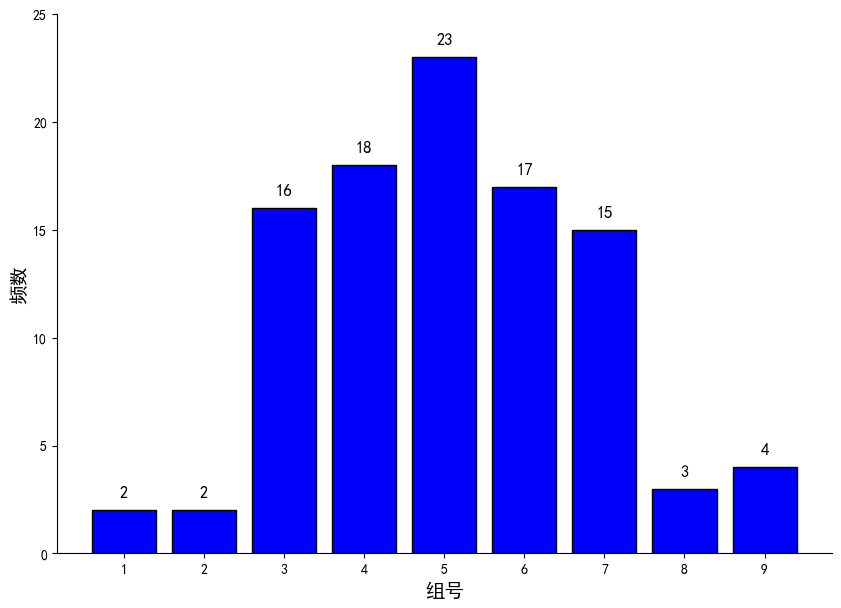

In [18]:
import matplotlib.pyplot as plt

# 数据
groups = [1, 2, 3, 4, 5, 6, 7, 8, 9]
freqs = [2, 2, 16, 18, 23, 17, 15, 3, 4]

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘图
plt.figure(figsize=(10, 7))
bars = plt.bar(groups, freqs, color='blue',edgecolor='black')

# 在每个柱子上方标注频数
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=12
    )

# 设置坐标轴和标签
plt.ylabel('频数', fontsize=14)
plt.xlabel('组号', fontsize=14)
plt.xticks(groups)  # 强制显示所有组号
plt.ylim(0, 25)      # y轴范围与原图匹配
plt.grid(False)

# 隐藏上、右边框
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()